# Ford GoBike Trip Data Analysis

## 1. Introduction

### Dataset Description
The dataset used in this project contains information about Ford GoBike bike-sharing trips recorded during February 2019. It includes information about trip duration, start and end stations, user type, gender, birth year, and bike details.

### Dataset Source
The dataset is part of the Ford GoBike bike-sharing system trip data for February 2019.

### Main Questions

In this project, I will explore the following questions:
1. What is the distribution of trip durations?
2. Which user type makes more trips?
3. How does trip duration differ between user types?
4. How is the age distribution of users?
5. How does gender relate to trip duration and user activity?
6. Which start stations are the most frequently used?
7. What patterns and relationships can be found in the dataset?
8. What recommendations can be made based on the analysis?

## 2. Preliminary Wrangling

### 2.1 Import Libraries

In [125]:
import sys
import os

sys.path.append(os.path.abspath('..'))

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_data, clean_data

### 2.2 Load Dataset

In [127]:
df = load_data('../Data/fordgobike-tripdataFor201902.csv')

In [128]:
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,32:10.1,01:56.0,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,53:21.8,42:03.1,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,13:13.2,24:08.1,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,54:26.0,02:36.8,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,54:18.5,20:44.1,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


### 2.3 Initial Data Inspection

In this step, I will inspect the dataset structure, dimensions, data types, and basic information to understand the data before starting the assessment and cleaning process.

In [129]:
df.shape

(183416, 16)

In [130]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 183416 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183416 non-null  int64  
 1   start_time               183416 non-null  str    
 2   end_time                 183416 non-null  str    
 3   start_station_id         183219 non-null  float64
 4   start_station_name       183219 non-null  str    
 5   start_station_latitude   183416 non-null  float64
 6   start_station_longitude  183416 non-null  float64
 7   end_station_id           183219 non-null  float64
 8   end_station_name         183219 non-null  str    
 9   end_station_latitude     183416 non-null  float64
 10  end_station_longitude    183416 non-null  float64
 11  bike_id                  183416 non-null  int64  
 12  user_type                183416 non-null  str    
 13  member_birth_year        175151 non-null  float64
 14  member_gender  

In [131]:
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183416.000000,183219.000000,183416.000000,183416.000000,183219.000000,183416.000000,183416.000000,183416.000000,175151.000000
mean,726.067311,138.590365,37.771221,-122.352661,136.249401,37.771425,-122.352247,4472.890260,1984.806504
std,1794.371831,111.778938,0.099586,0.117100,111.514916,0.099494,0.116677,1664.386068,10.116589
min,61.000000,3.000000,37.317298,-122.453705,3.000000,37.317298,-122.453705,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


In [132]:
df.dtypes

duration_sec                 int64
start_time                     str
end_time                       str
start_station_id           float64
start_station_name             str
start_station_latitude     float64
start_station_longitude    float64
end_station_id             float64
end_station_name               str
end_station_latitude       float64
end_station_longitude      float64
bike_id                      int64
user_type                      str
member_birth_year          float64
member_gender                  str
bike_share_for_all_trip        str
dtype: object

### 2.4 Check for Duplicates

I will check for duplicated rows to ensure that each trip is represented only once.

In [133]:
df.duplicated().sum()

np.int64(4)

In [134]:
df[df.duplicated()]

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
183412,313,05:34.7,10:48.5,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,66.0,3rd St at Townsend St,37.778742,-122.392741,4960,Subscriber,1984.0,Male,No
183413,141,06:05.5,08:27.2,278.0,The Alameda at Bush St,37.331932,-121.904888,277.0,Morrison Ave at Julian St,37.333658,-121.908586,3824,Subscriber,1990.0,Male,Yes
183414,139,05:34.4,07:54.3,220.0,San Pablo Ave at MLK Jr Way,37.811351,-122.273422,216.0,San Pablo Ave at 27th St,37.817827,-122.275698,5095,Subscriber,1988.0,Male,No
183415,271,00:20.6,04:52.1,24.0,Spear St at Folsom St,37.789677,-122.390428,37.0,2nd St at Folsom St,37.785000,-122.395936,1057,Subscriber,1989.0,Male,No


## 3. Data Assessment

### 3.1 Data Quality Issues

The initial assessment revealed several data quality issues:

- Missing values are present in station information, member birth year, and member gender.
- Four duplicated rows were identified.
- The `start_time` and `end_time` columns are stored as strings instead of datetime values.
- Station IDs and member birth years are stored as floating-point numbers because of missing values.
- The `duration_sec` variable contains potential outliers, with a maximum value much higher than the median.

### 3.2 Missing Values Analysis

I will examine the number and percentage of missing values in each column to determine which variables require cleaning.

In [135]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df[missing_df['Missing Values'] > 0].sort_values(
    by='Missing Values',
    ascending=False
)

,Missing Values,Percentage
member_birth_year,8265,4.506150
member_gender,8265,4.506150
start_station_name,197,0.107406
start_station_id,197,0.107406
end_station_name,197,0.107406
end_station_id,197,0.107406


### 3.3 Duplicate Records

The dataset contains 4 duplicated rows. These duplicate records should be removed because they represent repeated observations and may affect the accuracy of the analysis.

In [136]:
df.duplicated().sum()

np.int64(4)

In [137]:
df = df.drop_duplicates()

In [138]:
df.duplicated().sum()

np.int64(0)

### 3.4 Data Type Assessment

The data types of the main columns were reviewed to determine whether they are appropriate for analysis.

The `start_time` and `end_time` columns are stored as strings. However, these values contain only time-like information in the format `MM:SS.f`, without the original date and hour components. Therefore, they cannot be reliably converted into complete datetime values for day- or hour-based analysis.

Station IDs and member birth years are stored as floating-point numbers because they contain missing values.

In [139]:
df[['start_time', 'end_time']].head(10)

,start_time,end_time
0,32:10.1,01:56.0
1,53:21.8,42:03.1
2,13:13.2,24:08.1
3,54:26.0,02:36.8
4,54:18.5,20:44.1
5,49:58.6,19:51.8
6,55:35.1,14:42.6
7,41:06.8,08:02.8
8,41:48.8,07:59.7
9,49:47.7,07:17.0


In [140]:
df['start_time'].iloc[0]

'32:10.1'

In [141]:
df['end_time'].iloc[0]

'01:56.0'

In [142]:
df['start_time'].unique()[:20]

<StringArray>
['32:10.1', '53:21.8', '13:13.2', '54:26.0', '54:18.5', '49:58.6', '55:35.1',
 '41:06.8', '41:48.8', '49:47.7', '57:57.2', '56:55.5', '45:12.7', '49:06.1',
 '56:26.8', '59:18.5', '50:41.6', '48:25.1', '49:01.9', '43:05.2']
Length: 20, dtype: str

In [143]:
df['end_time'].unique()[:20]

<StringArray>
['01:56.0', '42:03.1', '24:08.1', '02:36.8', '20:44.1', '19:51.8', '14:42.6',
 '08:02.8', '07:59.7', '07:17.0', '05:35.4', '05:21.7', '04:49.2', '04:21.9',
 '03:01.9', '02:47.2', '59:50.0', '59:40.1', '58:19.8', '57:39.8']
Length: 20, dtype: str

In [144]:
df['start_time'].str.len().value_counts()

start_time
7    183412
Name: count, dtype: int64

In [145]:
df['end_time'].str.len().value_counts()

end_time
7    183412
Name: count, dtype: int64

In [146]:
df['start_time'].iloc[100]

'58:55.6'

In [147]:
df['start_time'].iloc[-1]

'00:20.6'

In [148]:
with open("../Data/fordgobike-tripdataFor201902.csv", "r", encoding="utf-8") as f:
    for _ in range(5):
        print(f.readline().strip())

duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
52185,32:10.1,01:56.0,21,Montgomery St BART Station (Market St at 2nd St),37.7896254,-122.400811,13,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984,Male,No
42521,53:21.8,42:03.1,23,The Embarcadero at Steuart St,37.791464,-122.391034,81,Berry St at 4th St,37.77588,-122.39317,2535,Customer,,,No
61854,13:13.2,24:08.1,86,Market St at Dolores St,37.7693053,-122.4268256,3,Powell St BART Station (Market St at 4th St),37.78637527,-122.4049044,5905,Customer,1972,Male,No
36490,54:26.0,02:36.8,375,Grove St at Masonic Ave,37.77483629,-122.4465457,70,Central Ave at Fell St,37.77331088,-122.4442926,6638,Subscriber,1989,Other,No


### 3.5 Date and Time Data Quality Issue

The `start_time` and `end_time` columns are stored as strings in the format `MM:SS.f`, rather than complete datetime values. Therefore, the original date and hour information is not available in the current dataset.

Because the date and hour components are missing, time-based analyses such as trips by day of the week or trips by hour cannot be reliably performed using these columns.

In [149]:
print("Start Time Example:")
print(df['start_time'].head())

print("\nEnd Time Example:")
print(df['end_time'].head())

Start Time Example:
0    32:10.1
1    53:21.8
2    13:13.2
3    54:26.0
4    54:18.5
Name: start_time, dtype: str

End Time Example:
0    01:56.0
1    42:03.1
2    24:08.1
3    02:36.8
4    20:44.1
Name: end_time, dtype: str


In [150]:
print("Start Time unique formats:")
print(df['start_time'].str.len().value_counts())

print("\nEnd Time unique formats:")
print(df['end_time'].str.len().value_counts())

print("\nNumber of unique start times:", df['start_time'].nunique())
print("Number of unique end times:", df['end_time'].nunique())

Start Time unique formats:
start_time
7    183412
Name: count, dtype: int64

End Time unique formats:
end_time
7    183412
Name: count, dtype: int64

Number of unique start times: 35783
Number of unique end times: 35767


### 3.6 Outliers in Trip Duration

The IQR method was used to identify unusually long trips. The upper bound was calculated as 1,502.5 seconds, and 10,098 trips (5.51% of the dataset) were identified as statistical outliers. These trips were not removed because long-duration trips may represent legitimate usage rather than data-entry errors.

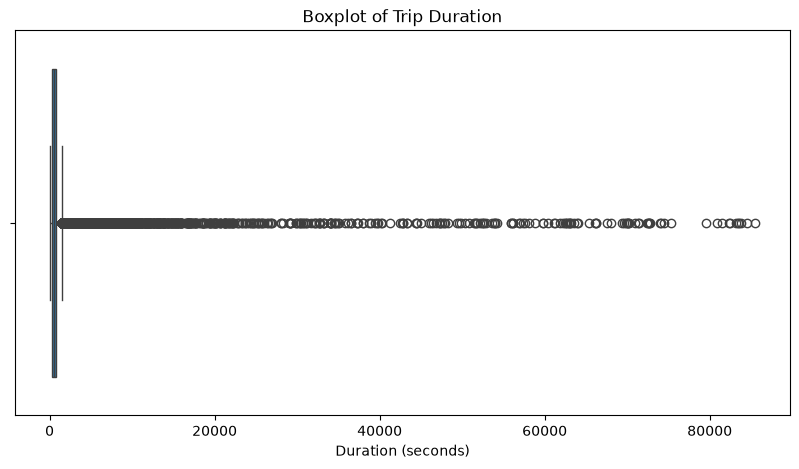

In [151]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['duration_sec'])

plt.title('Boxplot of Trip Duration')

plt.xlabel('Duration (seconds)')

plt.savefig('../outputs/figures/trip_duration_boxplot.png',
            bbox_inches='tight')

plt.show()

In [152]:
Q1 = df['duration_sec'].quantile(0.25)
Q3 = df['duration_sec'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 325.0
Q3: 796.0
IQR: 471.0
Lower Bound: -381.5
Upper Bound: 1502.5


In [153]:
outliers = df[df['duration_sec'] > upper_bound]

print("Number of outliers:", len(outliers))
print("Percentage of outliers:", (len(outliers) / len(df)) * 100)

Number of outliers: 10131
Percentage of outliers: 5.523629860641615


In [154]:
df['duration_sec'].sort_values(ascending=False).head(10)

101361    85444
85465     84548
153705    83772
127999    83519
112435    83407
5203      83195
95750     82512
173365    82385
8631      81549
176987    80891
Name: duration_sec, dtype: int64

In [155]:
duration_thresholds = [1500, 3600, 7200, 21600, 43200]

for threshold in duration_thresholds:
    count = (df['duration_sec'] > threshold).sum()
    percentage = (count / len(df)) * 100
    print(f"More than {threshold} seconds: {count} ({percentage:.2f}%)")

More than 1500 seconds: 10161 (5.54%)
More than 3600 seconds: 1710 (0.93%)
More than 7200 seconds: 712 (0.39%)
More than 21600 seconds: 197 (0.11%)
More than 43200 seconds: 99 (0.05%)


### Outlier Assessment

The IQR method identified 10,098 trips (5.51%) as statistical outliers, with durations above 1,502.5 seconds.

However, long trips are not necessarily data errors. Therefore, the identified outliers were not removed automatically, as some may represent valid long bike trips.

### 3.7 Data Types

The data types of the columns were reviewed to ensure that they are appropriate for analysis. Most columns have suitable data types, while some categorical columns are stored as strings. The `start_time` and `end_time` columns are also stored as strings because their original date and hour information is missing.

In [156]:
pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum()
})

,Data Type,Missing Values
duration_sec,int64,0
start_time,str,0
end_time,str,0
start_station_id,float64,197
start_station_name,str,197
start_station_latitude,float64,0
start_station_longitude,float64,0
end_station_id,float64,197
end_station_name,str,197
end_station_latitude,float64,0


### Data Types Assessment

Most columns have appropriate data types for analysis. The `duration_sec` and `bike_id` columns are stored as integers, while the station coordinates are stored as floating-point numbers.

The categorical columns are stored as strings, which is suitable for the planned analysis. The `start_time` and `end_time` columns are also stored as strings because their complete date and hour information is unavailable.

The station ID and birth year columns are stored as floating-point numbers due to the presence of missing values. These issues will be addressed during the data cleaning stage.

### 3.8 Invalid Values in Member Birth Year

The `member_birth_year` column was examined to identify potentially invalid or unrealistic birth years.

In [157]:
df['member_birth_year'].describe()

count    175147.000000
mean       1984.806437
std          10.116689
min        1878.000000
25%        1980.000000
50%        1987.000000
75%        1992.000000
max        2001.000000
Name: member_birth_year, dtype: float64

In [158]:
df['member_birth_year'].sort_values().head(10)

27370     1878.0
61611     1900.0
32285     1900.0
27675     1900.0
24042     1900.0
72819     1900.0
122194    1900.0
97721     1900.0
43880     1900.0
119010    1900.0
Name: member_birth_year, dtype: float64

In [159]:
birth_year_counts = df['member_birth_year'].value_counts().sort_index()

birth_year_counts[birth_year_counts.index < 1940]

member_birth_year
1878.0     1
1900.0    53
1901.0     6
1902.0    11
1910.0     1
1920.0     3
1927.0     1
1928.0     1
1930.0     1
1931.0    89
1933.0    20
1934.0     2
1938.0     3
1939.0    11
Name: count, dtype: int64

### Assessment of Member Birth Year

The `member_birth_year` column contains 203 records with birth years before 1940. These values are potentially unrealistic and may indicate data quality issues.

The earliest recorded birth year is 1878, while several records have birth years around 1900–1939. These values will be treated as potentially invalid and reviewed during the data cleaning stage.

No records are removed at this stage because data assessment is performed before applying cleaning decisions.

### 3.9 Categorical Values Assessment

The categorical columns were examined to identify unexpected, inconsistent, or invalid values.

In [160]:
categorical_columns = [
    'user_type',
    'member_gender',
    'bike_share_for_all_trip'
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


user_type:
user_type
Subscriber    163544
Customer       19868
Name: count, dtype: int64

member_gender:
member_gender
Male      130651
Female     40844
NaN         8265
Other       3652
Name: count, dtype: int64

bike_share_for_all_trip:
bike_share_for_all_trip
No     166053
Yes     17359
Name: count, dtype: int64


### Categorical Values Assessment

The categorical columns contain consistent and expected values. The `user_type` column contains two categories: `Subscriber` and `Customer`, while `bike_share_for_all_trip` contains `Yes` and `No`.

The `member_gender` column contains three valid categories: `Male`, `Female`, and `Other`. It also contains 8,265 missing values, which were identified during the missing values assessment.

No inconsistent categorical values were found.

## 4. Data Cleaning

In this section, the identified data quality issues will be addressed to prepare the dataset for further analysis.

In [161]:
df = clean_data(df)

In [162]:
station_columns = [
    'start_station_id',
    'start_station_name',
    'end_station_id',
    'end_station_name'
]

df = df.dropna(subset=station_columns)

print("Remaining rows:", len(df))

Remaining rows: 183215


The 197 records with missing station information were removed because station information is important for station-level analysis. Since these records represent a very small proportion of the dataset, removing them has a minimal impact on the overall dataset.

In [163]:
df[['member_birth_year', 'member_gender']].isnull().sum()

member_birth_year    8466
member_gender        8263
dtype: int64

### 4.1.1 Handling Missing Gender Values

The missing values in `member_gender` were replaced with `Unknown` instead of being removed or estimated. This preserves the trip records while clearly distinguishing missing gender information from known categories.

In [164]:
df['member_gender'] = df['member_gender'].fillna('Unknown')

In [165]:
df['member_gender'].value_counts(dropna=False)

member_gender
Male       130500
Female      40805
Unknown      8263
Other        3647
Name: count, dtype: int64

### 4.1.2 Handling Invalid Birth Years

The invalid birth years were converted to missing values. These missing values will be retained because estimating users' birth years could introduce inaccurate information into the dataset.

In [166]:
print("Missing birth years:", df['member_birth_year'].isnull().sum())

Missing birth years: 8466


In [167]:
df['member_birth_year'].describe()

count    174749.000000
mean       1984.877665
std           9.871342
min        1941.000000
25%        1980.000000
50%        1987.000000
75%        1992.000000
max        2001.000000
Name: member_birth_year, dtype: float64

### 4.2 Outlier Handling

The `duration_sec` column contains statistical outliers based on the IQR method. However, long trip durations are not necessarily data errors. Therefore, the identified outliers were not removed.

Keeping these values preserves potentially valid long-duration trips and avoids introducing assumptions about the correct trip duration.

### 4.3 Cleaning Verification

After the cleaning steps, the dataset was checked again to verify that the identified data quality issues were handled correctly.

In [168]:
print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (183215, 18)
Duplicate rows: 0

Missing values:
duration_sec                  0
start_time                    0
end_time                      0
start_station_id              0
start_station_name            0
start_station_latitude        0
start_station_longitude       0
end_station_id                0
end_station_name              0
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8466
member_gender                 0
bike_share_for_all_trip       0
duration_min                  0
member_age                 8466
dtype: int64


The cleaning process was successfully completed. Duplicate records were removed, records with missing station information were excluded, missing gender values were labeled as `Unknown`, and invalid birth years were converted to missing values. The remaining missing birth year values were retained because they are not required for analyses that do not involve age.

## 5. Exploratory Data Analysis (EDA)

### 5.1 Univariate Analysis

### 5.1.1 Distribution of Trip Duration

The trip duration distribution is right-skewed, with most trips being relatively short. The median trip duration is approximately 8.57 minutes, while the mean is approximately 12.10 minutes. The difference between the mean and median is mainly caused by a small number of unusually long trips.

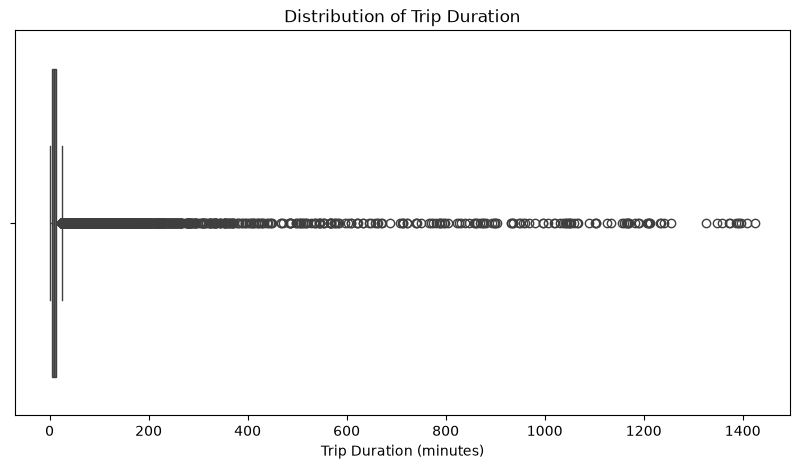

In [169]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['duration_min'])

plt.title('Distribution of Trip Duration')

plt.xlabel('Trip Duration (minutes)')

plt.savefig('../outputs/figures/trip_duration_distribution.png',
            bbox_inches='tight')

plt.show()

### 5.1.2 Histogram of Trip Duration

The boxplot shows that trip duration is strongly right-skewed, with most trips concentrated at relatively short durations and a small number of very long trips.

To better visualize the distribution of typical trips, the histogram below focuses on trips lasting up to 60 minutes. This visualization limit is used only for clearer presentation and does not remove any data from the dataset.

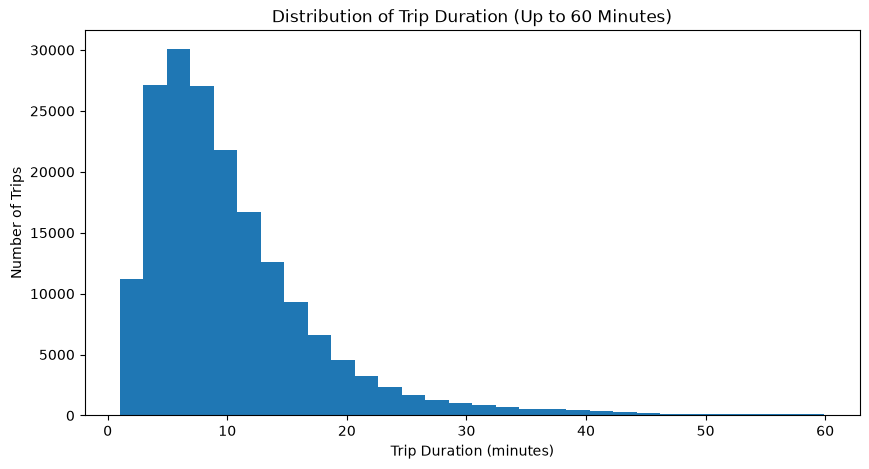

In [170]:
plt.figure(figsize=(10, 5))

plt.hist(df[df['duration_min'] <= 60]['duration_min'], bins=30)

plt.title('Distribution of Trip Duration (Up to 60 Minutes)')

plt.xlabel('Trip Duration (minutes)')

plt.ylabel('Number of Trips')

plt.savefig('../outputs/figures/trip_duration_histogram.png',
            bbox_inches='tight')

plt.show()

### Insight

Most bike trips are relatively short, with the highest concentration occurring between approximately 5 and 10 minutes. The number of trips decreases as trip duration increases, resulting in a right-skewed distribution.

This suggests that the bike-sharing service is mainly used for short-duration trips, while long-duration trips are less common.

### 5.1.3 Distribution of User Types

In [171]:
user_type_counts = df['user_type'].value_counts()

print(user_type_counts)

user_type
Subscriber    163414
Customer       19801
Name: count, dtype: int64


In [172]:
user_type_percentage = df['user_type'].value_counts(normalize=True) * 100

print(user_type_percentage)

user_type
Subscriber    89.192479
Customer      10.807521
Name: proportion, dtype: float64


### 5.1.4 User Type Distribution

Subscribers represent the vast majority of trips, with 163,544 trips compared with 19,868 trips by Customers. This indicates that the bike-sharing service was used primarily by subscribers during February 2019.

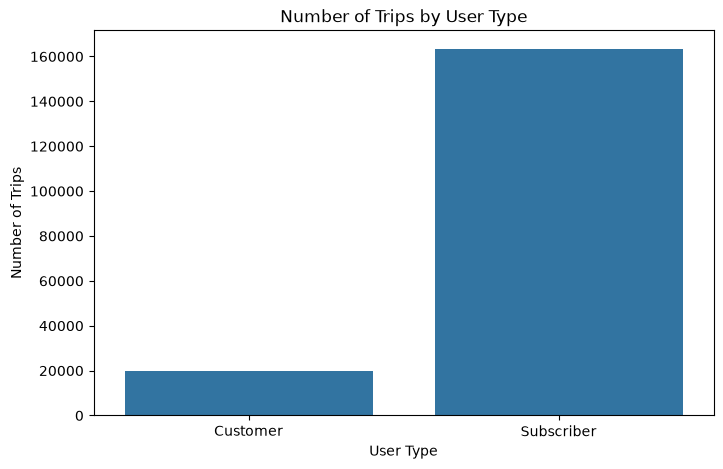

In [173]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='user_type')

plt.title('Number of Trips by User Type')

plt.xlabel('User Type')

plt.ylabel('Number of Trips')

plt.savefig('../outputs/figures/trips_by_user_type.png',
            bbox_inches='tight')

plt.show()

### Insight

Subscribers account for the vast majority of bike trips, with 163,544 trips compared with 19,868 trips made by Customers.

This indicates that Subscribers use the bike-sharing service much more frequently than Customers.

In [174]:
user_type_percentage = df['user_type'].value_counts(normalize=True) * 100

print(user_type_percentage)

user_type
Subscriber    89.192479
Customer      10.807521
Name: proportion, dtype: float64


### 5.1.5 Distribution of Gender

Male users represent the largest gender group, followed by Female users. A smaller number of users are categorized as Other, while 8,265 records have Unknown gender information. This shows that male users were the most active group in terms of trip count.

In [175]:
gender_counts = df['member_gender'].value_counts()

print(gender_counts)

member_gender
Male       130500
Female      40805
Unknown      8263
Other        3647
Name: count, dtype: int64


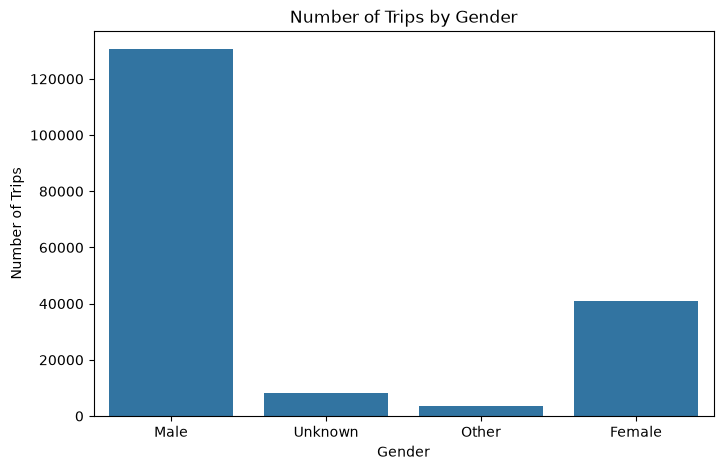

In [176]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='member_gender')

plt.title('Number of Trips by Gender')

plt.xlabel('Gender')

plt.ylabel('Number of Trips')

plt.savefig('../outputs/figures/trips_by_gender.png',
            bbox_inches='tight')

plt.show()

### Insight

Male users account for the largest number of bike trips, with 130,651 trips, followed by Female users with 40,844 trips. Other users account for 3,652 trips, while 8,265 trips have Unknown gender information.

This indicates that male users made significantly more trips than female users during the observed period.

### 5.1.6 Distribution of Member Age

The age distribution shows that most users are young adults. The median age is 32 years, while the mean age is approximately 34.12 years. The middle 50% of users are between 27 and 39 years old, with ages ranging from 18 to 78 years after cleaning.

In [177]:
print(df['member_age'].describe())

count    174749.000000
mean         34.122335
std           9.871342
min          18.000000
25%          27.000000
50%          32.000000
75%          39.000000
max          78.000000
Name: member_age, dtype: float64


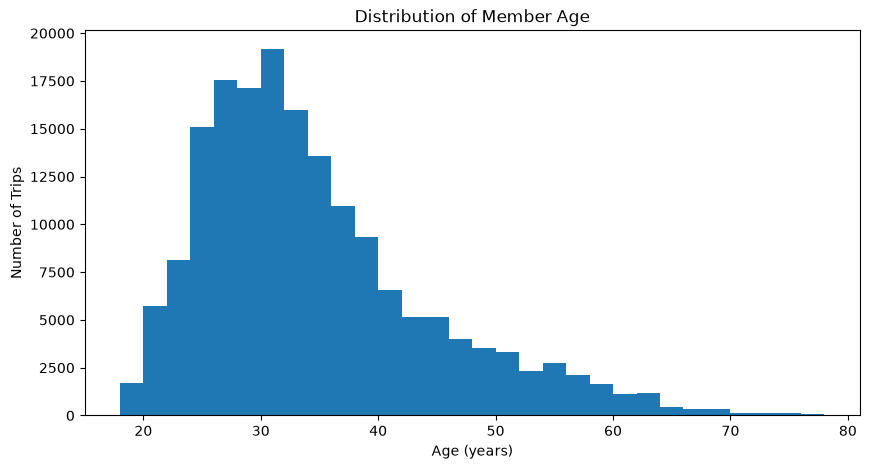

In [178]:
plt.figure(figsize=(10, 5))

plt.hist(df['member_age'].dropna(), bins=30)

plt.title('Distribution of Member Age')

plt.xlabel('Age (years)')

plt.ylabel('Number of Trips')

plt.savefig('../outputs/figures/member_age_distribution.png',
            bbox_inches='tight')

plt.show()

### Insight

The distribution of member age shows that most bike trips were made by relatively young adults. The median age is 32 years, while the mean age is approximately 34.12 years.

Most members are between 27 and 39 years old, indicating that the bike-sharing service was particularly popular among adults in this age range. The cleaned age values range from 18 to 78 years.

### 5.2.1 Trip Duration by User Type

Customers have noticeably longer trip durations than Subscribers. The median trip duration is approximately 13.18 minutes for Customers compared with 8.17 minutes for Subscribers. This suggests that Customers tend to use the service for longer individual trips.

In [179]:
df.groupby('user_type')['duration_min'].describe()

,count,mean,std,min,25%,50%,75%,max
user_type,,,,,,,,
Customer,19801.0,23.891262,64.459939,1.033333,8.4,13.183333,21.033333,1396.200000
Subscriber,163414.0,10.669413,21.936234,1.016667,5.2,8.166667,12.500000,1424.066667


### 5.2.2 Trip Duration by User Type

Customers have noticeably longer trip durations than Subscribers. The median trip duration is approximately 13.18 minutes for Customers compared with 8.17 minutes for Subscribers. This suggests that Customers tend to use the service for longer individual trips.

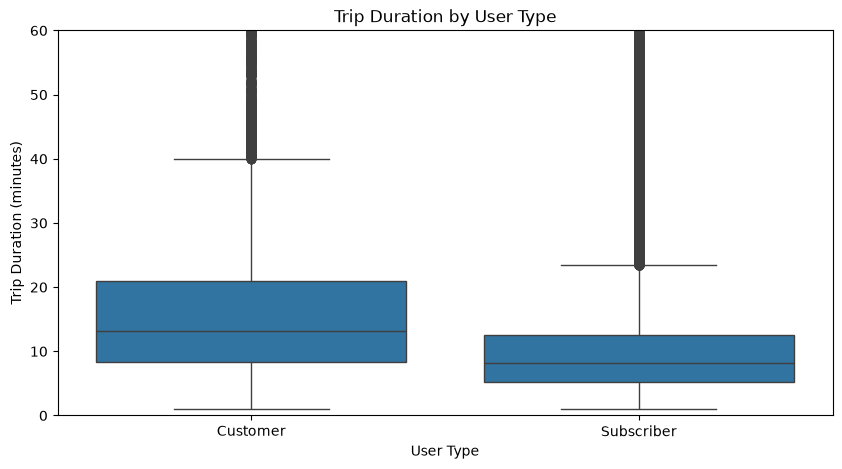

In [180]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x='user_type', y='duration_min')

plt.ylim(0, 60)

plt.title('Trip Duration by User Type')

plt.xlabel('User Type')

plt.ylabel('Trip Duration (minutes)')

plt.savefig('../outputs/figures/duration_by_user_type.png',
            bbox_inches='tight')

plt.show()

### Insight

Customers tend to have longer trip durations than Subscribers. The median trip duration for Customers is approximately 13.18 minutes, compared with 8.17 minutes for Subscribers.

This suggests that Customers may use the bike-sharing service for longer, more occasional trips, while Subscribers tend to make shorter and more frequent trips.

### 5.2.3 Trip Duration by Gender

Female users have a higher median trip duration than Male users, at approximately 9.45 minutes compared with 8.22 minutes. Other and Unknown groups also show relatively longer median durations. However, the differences between gender groups are smaller than the difference observed between user types.

In [181]:
df.groupby('member_gender')['duration_min'].describe()

,count,mean,std,min,25%,50%,75%,max
member_gender,,,,,,,,
Female,40805.0,12.981213,29.783394,1.016667,6.016667,9.450000,14.400000,1386.583333
Male,130500.0,11.206581,25.079909,1.016667,5.183333,8.216667,12.683333,1409.133333
Other,3647.0,16.622141,58.770767,1.050000,5.733333,9.266667,14.575000,1375.200000
Unknown,8263.0,19.826233,62.637761,1.033333,6.416667,10.100000,16.233333,1424.066667


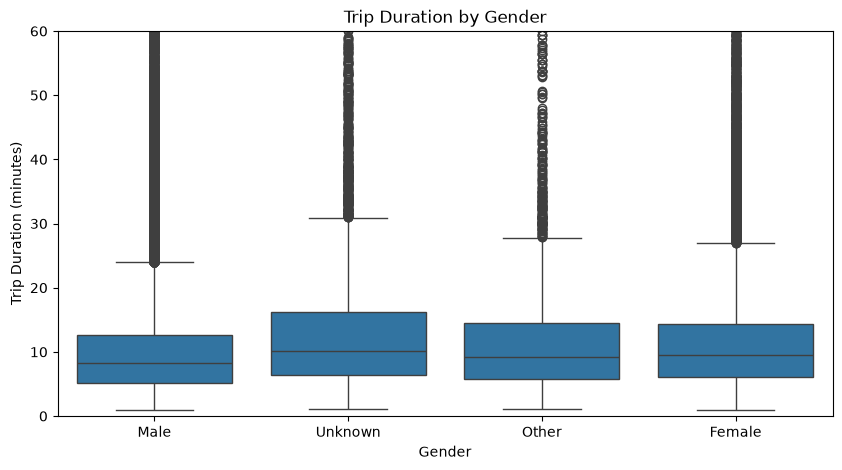

In [182]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x='member_gender', y='duration_min')

plt.ylim(0, 60)

plt.title('Trip Duration by Gender')

plt.xlabel('Gender')

plt.ylabel('Trip Duration (minutes)')

plt.savefig('../outputs/figures/duration_by_gender.png',
            bbox_inches='tight')

plt.show()

### Insight

Female users have a slightly higher median trip duration than Male users, with median durations of approximately 9.45 and 8.22 minutes, respectively.

The Other and Unknown categories show higher average and median trip durations, but these groups contain far fewer trips than Male and Female users.

Overall, trip durations are relatively similar across the main gender categories, although Female users tend to have slightly longer trips than Male users.

### 5.2.4 Age vs. Trip Duration

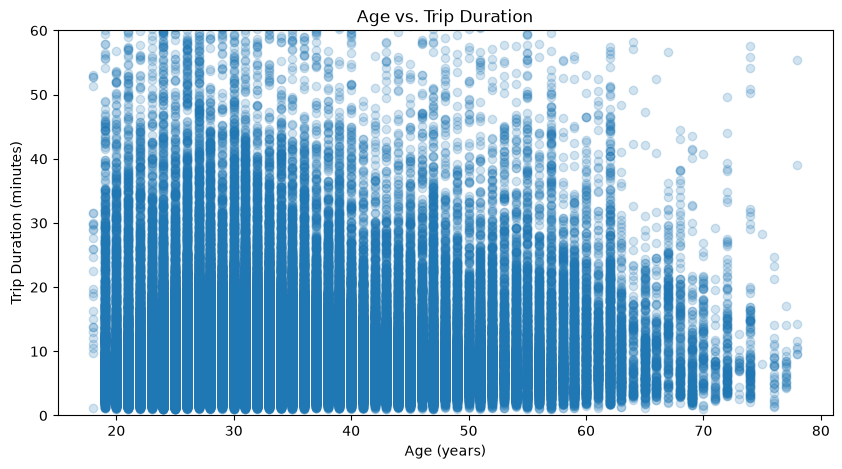

In [183]:
plt.figure(figsize=(10, 5))

plt.scatter(df['member_age'], df['duration_min'], alpha=0.2)

plt.ylim(0, 60)

plt.title('Age vs. Trip Duration')

plt.xlabel('Age (years)')

plt.ylabel('Trip Duration (minutes)')

plt.savefig('../outputs/figures/age_vs_duration.png',
            bbox_inches='tight')

plt.show()

### Insight

The scatter plot does not show a strong relationship between member age and trip duration. Most trips are relatively short across different age groups, while a small number of longer trips appear across the age range.

This suggests that member age is not a major factor in determining trip duration in this dataset.

### 5.3.1 Trip Duration by User Type and Gender

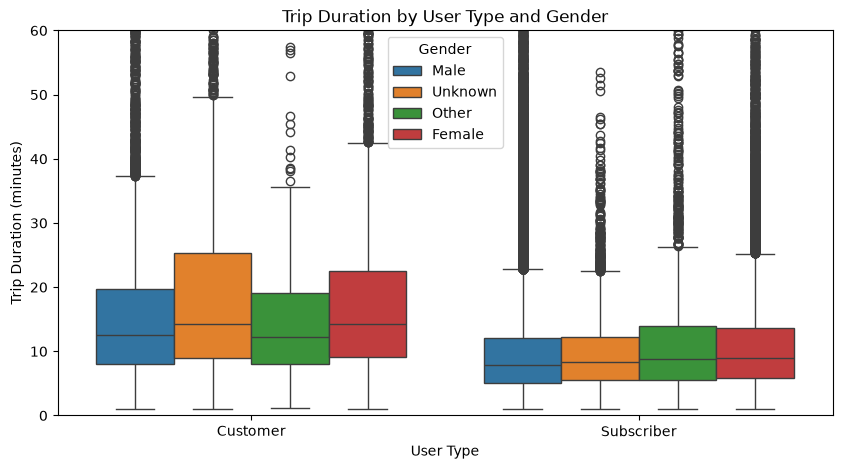

In [184]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x='user_type',
    y='duration_min',
    hue='member_gender'
)

plt.ylim(0, 60)

plt.title('Trip Duration by User Type and Gender')

plt.xlabel('User Type')

plt.ylabel('Trip Duration (minutes)')

plt.legend(title='Gender')

plt.savefig('../outputs/figures/duration_user_type_gender.png',
            bbox_inches='tight')

plt.show()

### Insight

Trip duration varies between user types across gender categories. In general, Customers tend to have longer trips than Subscribers for both Male and Female users.

The differences between Male and Female users are relatively small compared with the difference between Customers and Subscribers. This suggests that user type has a stronger relationship with trip duration than gender.

### 5.3.2 Most Popular Start Stations

Market St at 10th St is the most frequently used starting station, followed by San Francisco Caltrain Station 2 and Berry St at 4th St. Several of the most popular stations are located near major transportation and commercial areas, suggesting strong demand around transit hubs and central parts of San Francisco.

In [185]:
top_stations = df['start_station_name'].value_counts().head(10)

print(top_stations)

start_station_name
Market St at 10th St                                         3904
San Francisco Caltrain Station 2  (Townsend St at 4th St)    3544
Berry St at 4th St                                           3052
Montgomery St BART Station (Market St at 2nd St)             2895
Powell St BART Station (Market St at 4th St)                 2760
San Francisco Ferry Building (Harry Bridges Plaza)           2710
San Francisco Caltrain (Townsend St at 4th St)               2703
Powell St BART Station (Market St at 5th St)                 2327
Howard St at Beale St                                        2293
Steuart St at Market St                                      2283
Name: count, dtype: int64


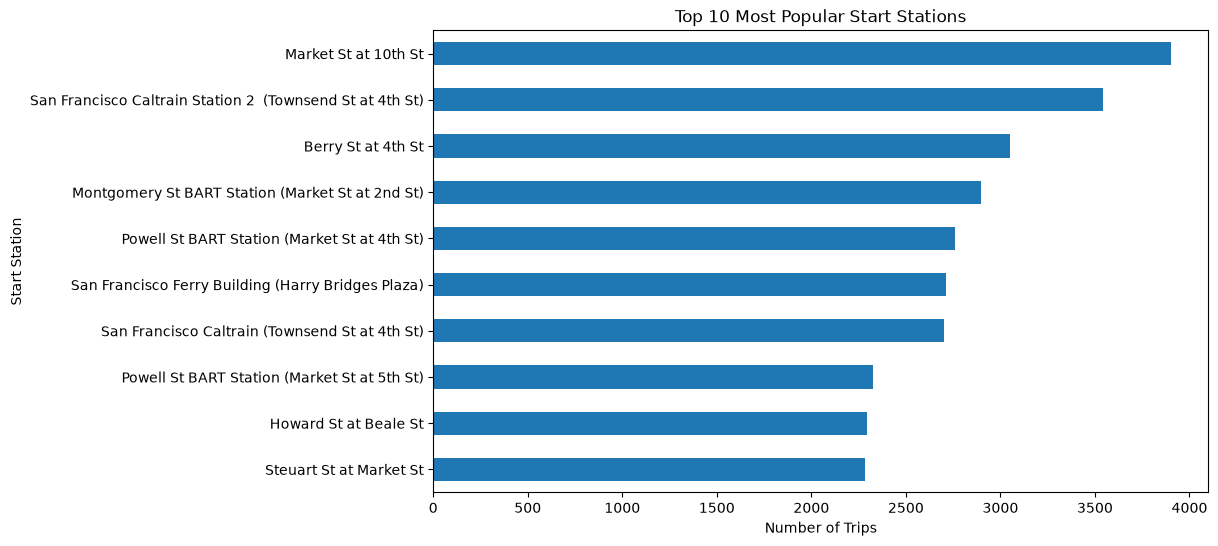

In [186]:
plt.figure(figsize=(10, 6))

top_stations.sort_values().plot(kind='barh')

plt.title('Top 10 Most Popular Start Stations')

plt.xlabel('Number of Trips')

plt.ylabel('Start Station')

plt.savefig('../outputs/figures/top_start_stations.png',
            bbox_inches='tight')

plt.show()

### Insight

Market St at 10th St was the most frequently used starting station, with 3,904 trips. It was followed by San Francisco Caltrain Station 2 with 3,544 trips and Berry St at 4th St with 3,052 trips.

The top 10 starting stations are mainly located around major transportation and downtown areas, such as Caltrain stations, BART stations, and the Ferry Building. This suggests that bike-sharing is frequently used around important transportation hubs and central areas.

## 6. Conclusions

The analysis of the Ford GoBike February 2019 dataset revealed several important patterns.

Most trips were relatively short, with a median duration of approximately 8.57 minutes. The distribution was right-skewed because of a relatively small number of unusually long trips. Using the IQR method, 10,098 trips (5.51%) were identified as statistical outliers, but they were retained because they may represent legitimate trips.

Subscribers made the majority of trips, with 163,544 trips compared with 19,868 trips by Customers. However, Customers had longer trips on average, with a median duration of approximately 13.18 minutes compared with 8.17 minutes for Subscribers.

Gender analysis showed that Male users represented the largest group. Female users had a slightly higher median trip duration than Male users, at approximately 9.45 minutes compared with 8.22 minutes. However, the differences between gender groups were smaller than the differences observed between user types.

The age analysis showed that most users were young adults, with a median age of 32 years and a mean age of approximately 34.12 years. Most users were between 27 and 39 years old.

The most frequently used starting stations were concentrated around major transportation and commercial areas, particularly Market Street and Caltrain stations.

Overall, the analysis suggests that user type has a stronger relationship with trip duration than gender, while station location plays an important role in overall trip demand.

## 7. Recommendations

Based on the findings of this analysis, the following recommendations can be considered:

1. **Focus on Subscribers:** Since Subscribers account for the majority of trips, improving membership benefits and maintaining reliable service for subscribers could help retain frequent users.

2. **Target Customers:** Customers tend to take longer trips than Subscribers. Promotional offers or membership plans designed for occasional users could encourage Customers to become regular Subscribers.

3. **Optimize Bike Availability:** The most popular starting stations should receive special attention to ensure sufficient bike availability during periods of high demand.

4. **Focus on Transportation Hubs:** Since many popular starting stations are located near major transportation and downtown areas, maintaining strong bike availability around these locations could improve the overall user experience.

5. **Improve Service Planning:** Trip duration and station usage patterns can be used to support better bike distribution and operational planning.

## 8. Final Conclusion

Overall, the analysis shows that the Ford GoBike service was primarily used for short trips by Subscribers, particularly among young adults. Customers tended to take longer trips, while age had little apparent relationship with trip duration. The analysis also identified several highly active starting stations, especially around major transportation and central areas.

These findings can help bike-sharing operators improve bike distribution, strengthen membership strategies, and focus resources on stations with high demand.